## 1. Setup — Import Libraries

In [1]:
# Import all libraries required for data manipulation, analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot styling settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")


Libraries imported successfully


## 2. Load the Dataset

In [2]:
# How do we load the dataset into a DataFrame?
df = pd.read_csv("Netflix_Dataset.csv")
print("Dataset loaded. Shape:", df.shape)


Dataset loaded. Shape: (7789, 11)


In [3]:
# What does the raw data look like (first 5 rows)?
df.head()


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
# What does the raw data look like (last 5 rows)?
df.tail()


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [5]:
# What are the column names and data types of each column?
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show_Id       7789 non-null   str  
 1   Category      7789 non-null   str  
 2   Title         7789 non-null   str  
 3   Director      5401 non-null   str  
 4   Cast          7071 non-null   str  
 5   Country       7282 non-null   str  
 6   Release_Date  7779 non-null   str  
 7   Rating        7782 non-null   str  
 8   Duration      7789 non-null   str  
 9   Type          7789 non-null   str  
 10  Description   7789 non-null   str  
dtypes: str(11)
memory usage: 669.5 KB


In [6]:
# What is the shape of the dataset (rows, columns)?
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 7789
Number of columns: 11


In [7]:
# What are basic descriptive statistics of the (object/categorical) columns?
df.describe(include='object')


/tmp/ipykernel_478/1167555298.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


## 3. Data Cleaning

In [8]:
# Are there any duplicate rows in the dataset?
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 2


In [9]:
# Are there any duplicate Show_Id values (should be unique identifiers)?
print("Duplicate Show_Id count:", df['Show_Id'].duplicated().sum())


Duplicate Show_Id count: 2


In [10]:
# How many missing values does each column have, and what percentage of the data is missing?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_df


,Missing_Count,Missing_Percent
Director,2388,30.66
Cast,718,9.22
Country,507,6.51
Release_Date,10,0.13
Rating,7,0.09


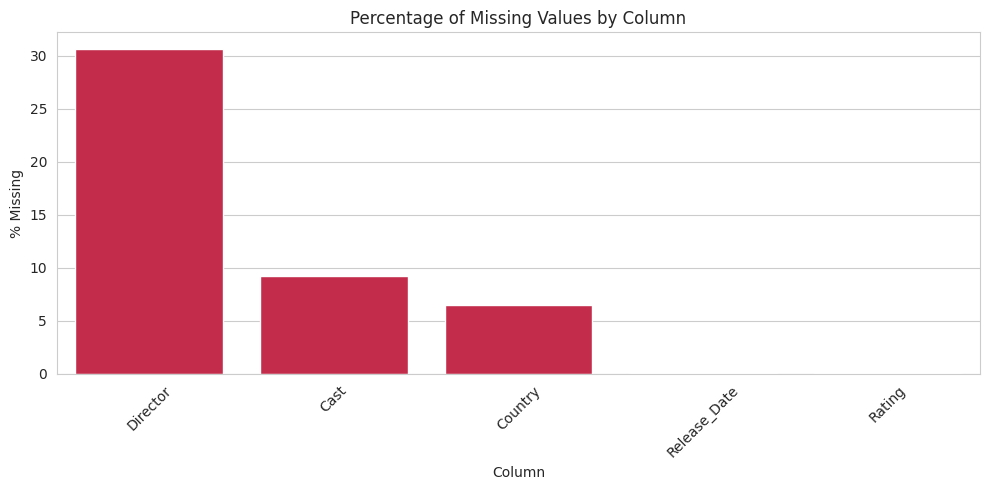

In [11]:
#visualize the missing values across columns?
plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y=missing_df['Missing_Percent'], color='crimson')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('% Missing')
plt.xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
# handle the missing values (Director, Cast, Country, Rating, Release_Date)?

df['Director'] = df['Director'].fillna('Unknown')
df['Cast'] = df['Cast'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna(df['Rating'].mode()[0])
df = df.dropna(subset=['Release_Date'])

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64


In [13]:
# convert Release_Date into a proper datetime type, and extract useful features from it?
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year
df['Release_Month'] = df['Release_Date'].dt.month_name()

# Drop any rows where date conversion failed
df = df.dropna(subset=['Release_Date'])
df['Release_Year'] = df['Release_Year'].astype(int)

print(df[['Release_Date','Release_Year','Release_Month']].head())


  Release_Date  Release_Year Release_Month
0   2020-08-14          2020        August
1   2016-12-23          2016      December
2   2018-12-20          2018      December
3   2017-11-16          2017      November
4   2020-01-01          2020       January


In [14]:
# separate the Duration column into numeric value + unit (minutes for Movies, Seasons for TV Shows)?
df['Duration_Value'] = df['Duration'].str.extract(r'(\d+)').astype(float)
df['Duration_Unit'] = df['Duration'].str.extract(r'([a-zA-Z]+)')

print(df[['Category','Duration','Duration_Value','Duration_Unit']].head())


  Category   Duration  Duration_Value Duration_Unit
0  TV Show  4 Seasons             4.0       Seasons
1    Movie     93 min            93.0           min
2    Movie     78 min            78.0           min
3    Movie     80 min            80.0           min
4    Movie    123 min           123.0           min


In [15]:
# What is the final shape of the cleaned dataset?
print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (7691, 15)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,Release_Year,Release_Month,Duration_Value,Duration_Unit
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,August,4.0,Seasons
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,December,93.0,min
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,December,78.0,min
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,November,80.0,min
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,January,123.0,min


## 4. Univariate Analysis

Category
Movie      5379
TV Show    2312
Name: count, dtype: int64


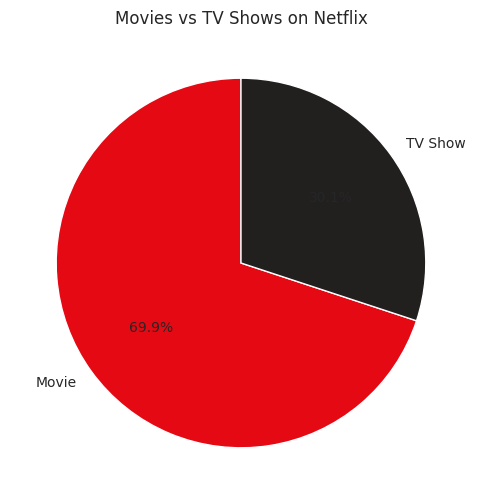

In [16]:
# What is the split between Movies and TV Shows (Category column)?
category_counts = df['Category'].value_counts()
print(category_counts)

plt.figure(figsize=(6,6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
        colors=['#E50914','#221f1f'], startangle=90)
plt.title('Movies vs TV Shows on Netflix')
plt.show()


In [17]:
# How many unique titles, directors, cast members, and countries are represented?
print("Unique Titles:", df['Title'].nunique())
print("Unique Directors:", df['Director'].nunique())
print("Unique Countries (raw, incl. multi-country strings):", df['Country'].nunique())
print("Unique Content Ratings:", df['Rating'].nunique())


Unique Titles: 7689
Unique Directors: 4047
Unique Countries (raw, incl. multi-country strings): 678
Unique Content Ratings: 14


/tmp/ipykernel_478/852812676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Rating', order=order, palette='magma')


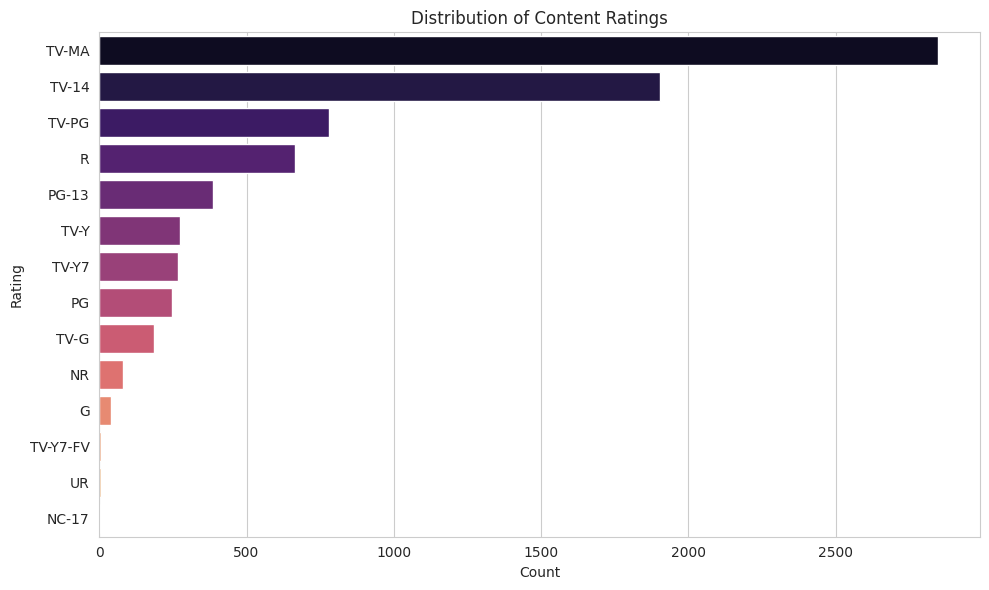

In [18]:
# What is the distribution of content Ratings?
plt.figure(figsize=(10,6))
order = df['Rating'].value_counts().index
sns.countplot(data=df, y='Rating', order=order, palette='magma')
plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


Country
United States     3250
India              989
United Kingdom     703
Canada             399
France             345
Japan              283
Spain              211
South Korea        207
Germany            198
Mexico             154
Name: count, dtype: int64


/tmp/ipykernel_478/2909076920.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


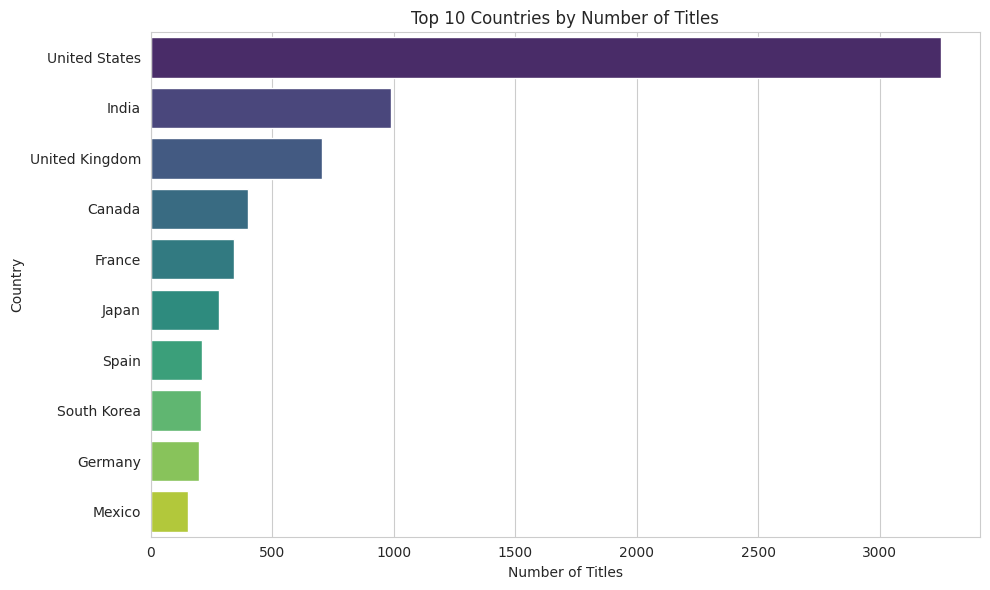

In [19]:
# Which top 10 countries produce the most content on Netflix?

country_series = df['Country'].str.split(', ').explode()
top_countries = country_series[country_series != 'Unknown'].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


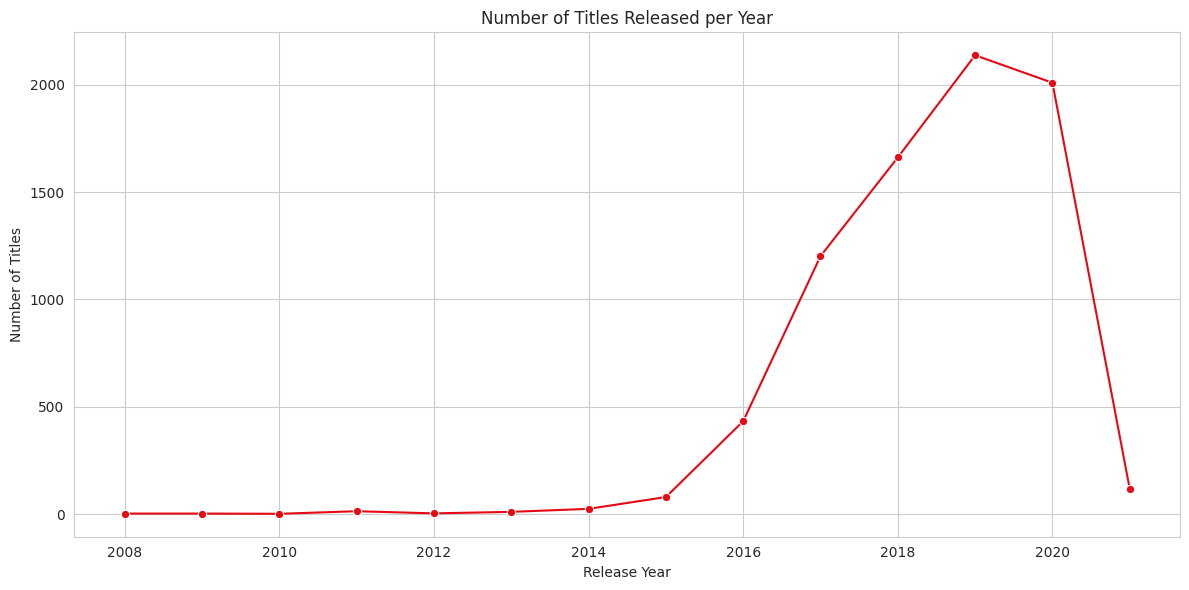

In [20]:
#the number of titles released on Netflix changed over the years?
year_counts = df['Release_Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#E50914')
plt.title('Number of Titles Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


/tmp/ipykernel_478/3287020152.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='coolwarm')


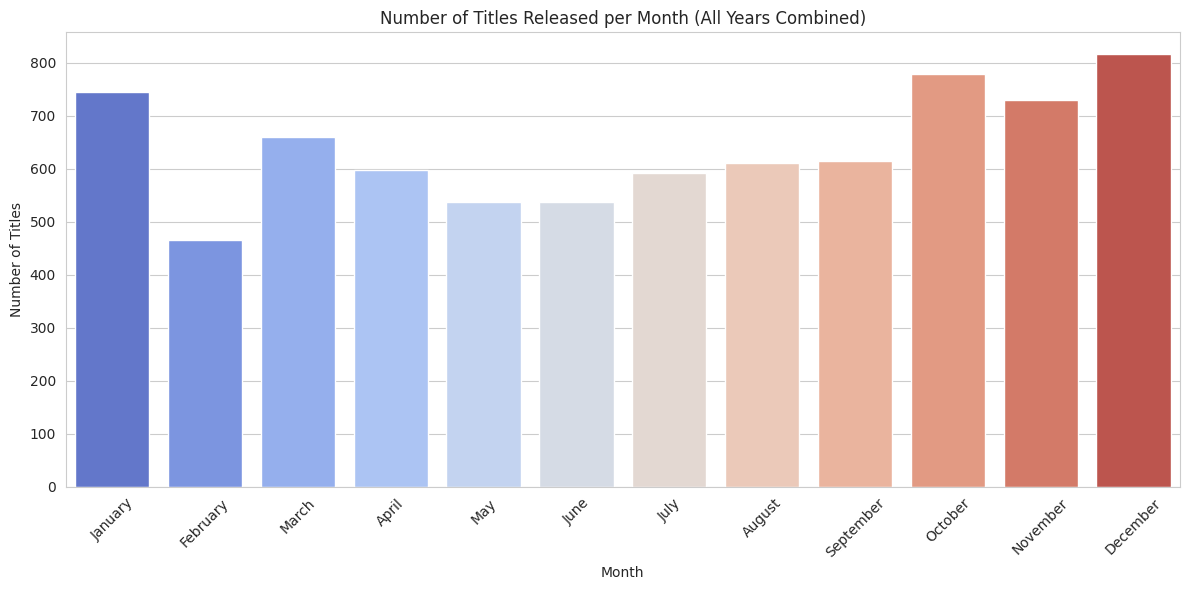

In [21]:
# In which month are most titles released ?
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_counts = df['Release_Month'].value_counts().reindex(month_order)

plt.figure(figsize=(12,6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='coolwarm')
plt.title('Number of Titles Released per Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


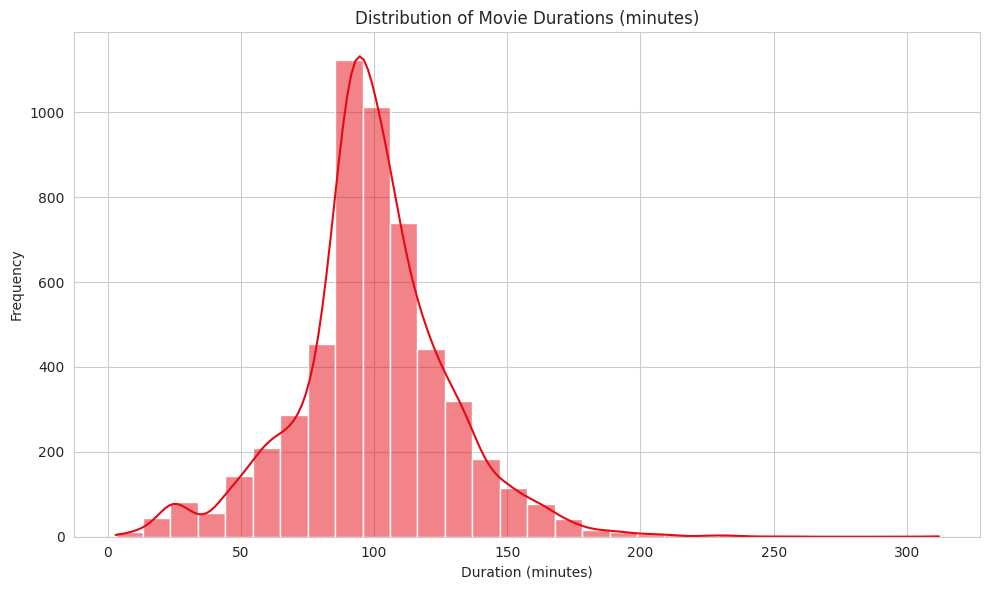

Average movie duration: 99.3 minutes
Median movie duration: 98.0 minutes


In [22]:
# What is the distribution of Movie durations (in minutes)?
movie_durations = df[df['Category'] == 'Movie']['Duration_Value']

plt.figure(figsize=(10,6))
sns.histplot(movie_durations, bins=30, kde=True, color='#E50914')
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average movie duration:", round(movie_durations.mean(), 1), "minutes")
print("Median movie duration:", movie_durations.median(), "minutes")


/tmp/ipykernel_478/1419038042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=tv_durations, palette='mako')


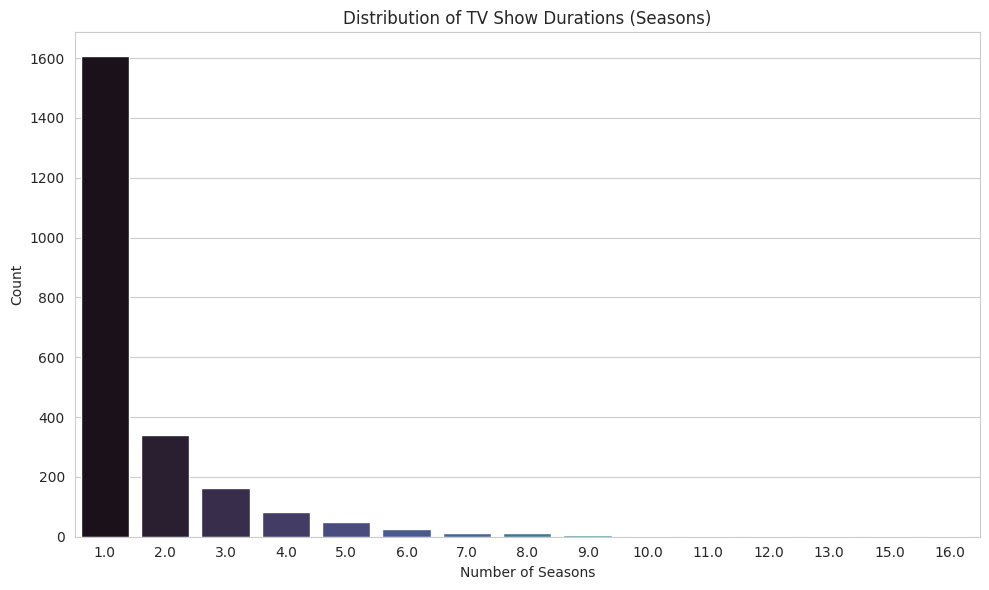

Percentage of TV shows with only 1 season: 69.5 %


In [23]:
# What is the distribution of TV Show durations (in number of Seasons)?
tv_durations = df[df['Category'] == 'TV Show']['Duration_Value']

plt.figure(figsize=(10,6))
sns.countplot(x=tv_durations, palette='mako')
plt.title('Distribution of TV Show Durations (Seasons)')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Percentage of TV shows with only 1 season:",
      round((tv_durations == 1).mean() * 100, 1), "%")


## 5. Genre / Type (Listed-in) Analysis

/tmp/ipykernel_478/2145504327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')


Type
International Movies        2437
Dramas                      2108
Comedies                    1472
International TV Shows      1176
Documentaries                786
Action & Adventure           721
TV Dramas                    680
Independent Movies           675
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  494
Thrillers                    492
Crime TV Shows               416
Kids' TV                     396
Docuseries                   338
Name: count, dtype: int64


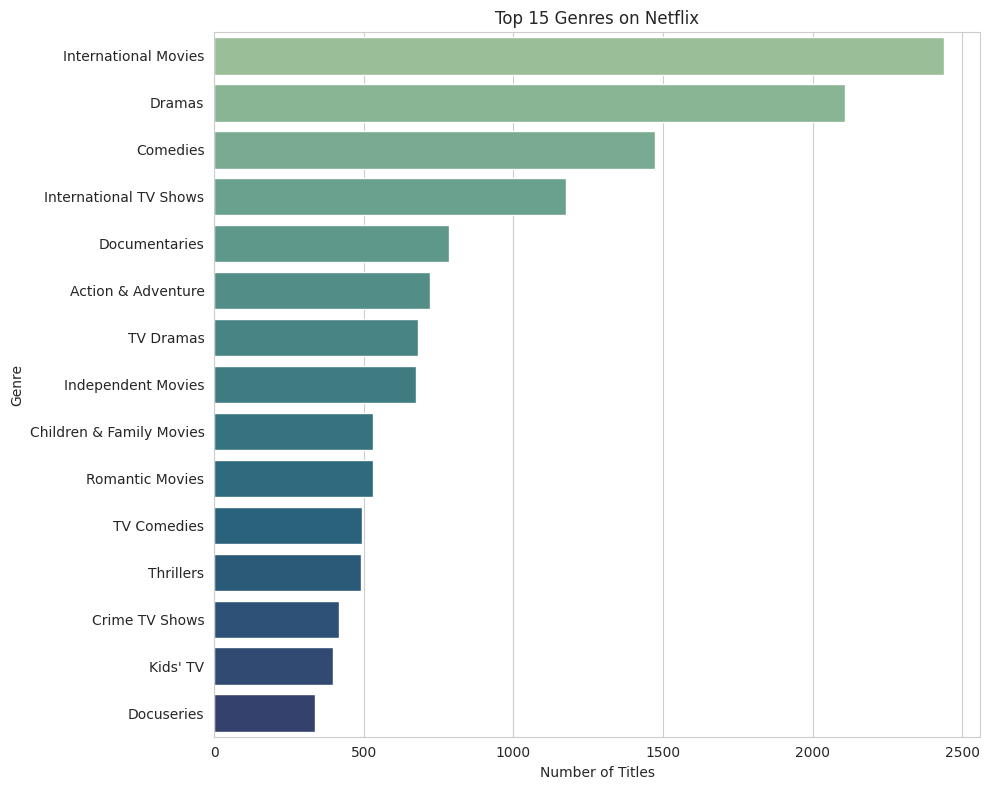

In [24]:
# What are the most common genres (the 'Type' column lists genres, comma-separated)?
genre_series = df['Type'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(15)
print(top_genres)

plt.figure(figsize=(10,8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


In [25]:
# How many genres, on average, does a title belong to?
df['Genre_Count'] = df['Type'].str.split(', ').apply(len)
print("Average number of genres per title:", round(df['Genre_Count'].mean(), 2))
df['Genre_Count'].value_counts().sort_index()


Average number of genres per title: 2.19


Genre_Count
1    1774
2    2651
3    3266
Name: count, dtype: int64

## 6. Multivariate Analysis (Relationships Between Variables)

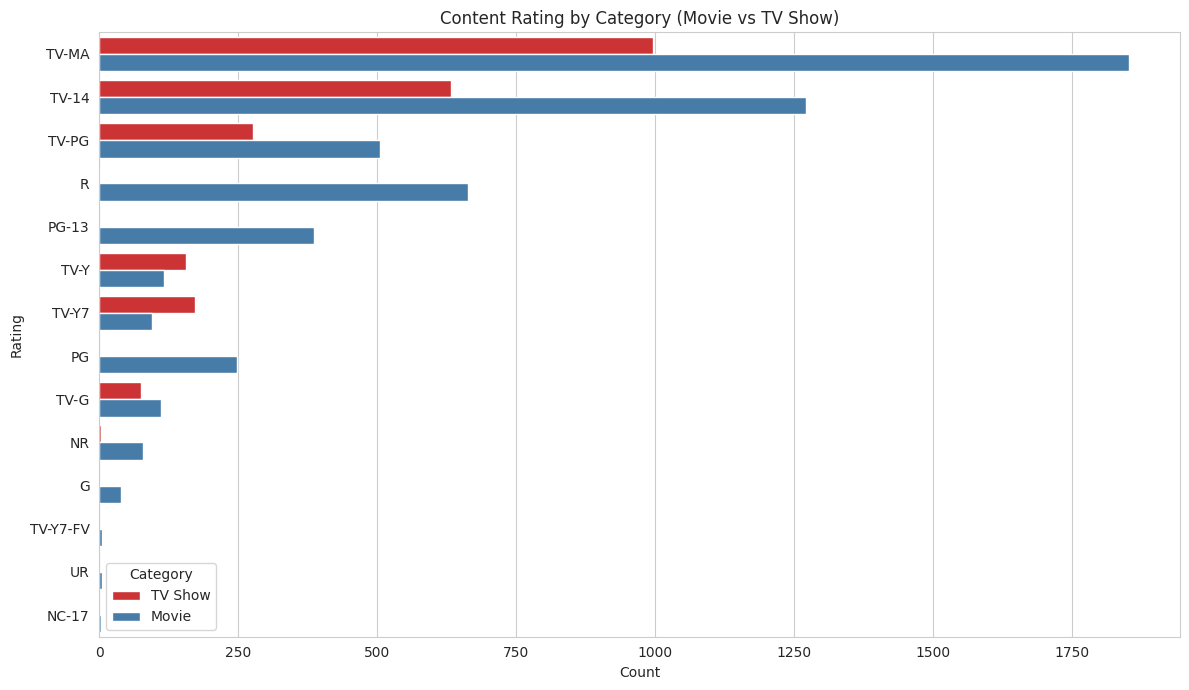

In [26]:
#the distribution of content Rating differ between Movies and TV Shows?
plt.figure(figsize=(12,7))
order = df['Rating'].value_counts().index
sns.countplot(data=df, y='Rating', hue='Category', order=order, palette='Set1')
plt.title('Content Rating by Category (Movie vs TV Show)')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


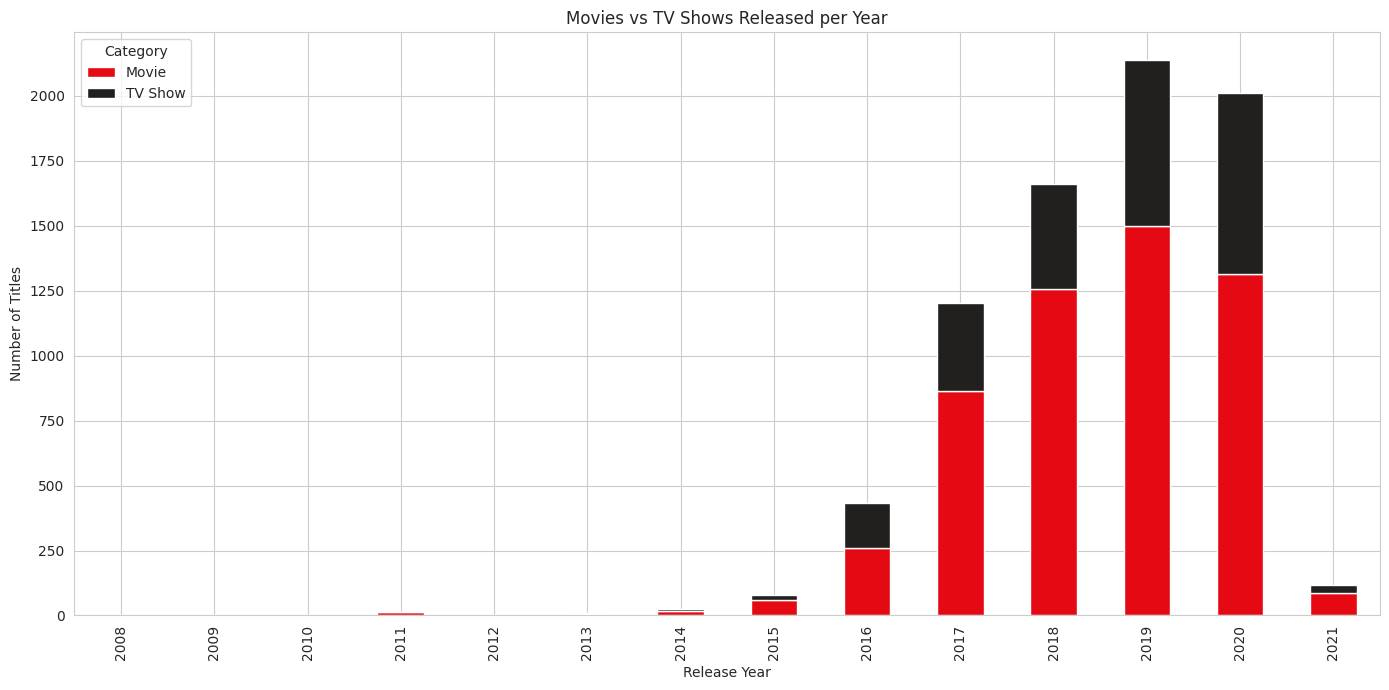

In [27]:
# the Movie vs TV Show ratio changed over time (has Netflix shifted focus to TV Shows)?
year_cat = df.groupby(['Release_Year', 'Category']).size().unstack(fill_value=0)
year_cat = year_cat[year_cat.index >= 2008]  # focus on the streaming-relevant era

year_cat.plot(kind='bar', stacked=True, figsize=(14,7), color=['#E50914','#221f1f'])
plt.title('Movies vs TV Shows Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Category')
plt.tight_layout()
plt.show()


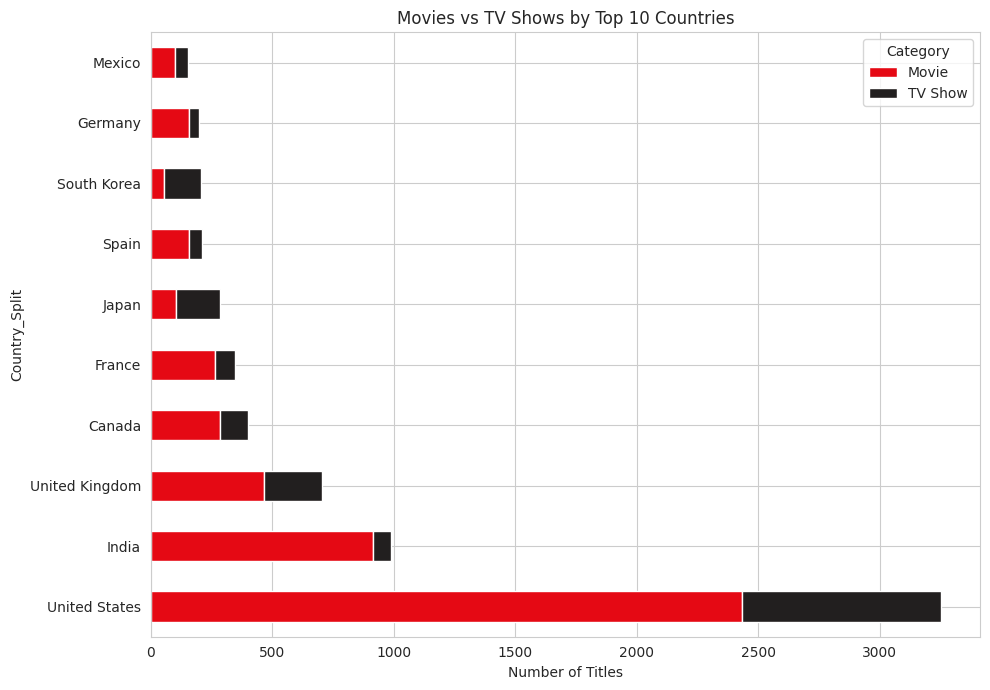

In [28]:
# Which countries produce more Movies vs more TV Shows (top 10 countries)?
top10_country_names = top_countries.index.tolist()
country_cat_df = df.assign(Country_Split=df['Country'].str.split(', ')).explode('Country_Split')
country_cat_df = country_cat_df[country_cat_df['Country_Split'].isin(top10_country_names)]

pivot = country_cat_df.groupby(['Country_Split','Category']).size().unstack(fill_value=0)
pivot = pivot.loc[top10_country_names]

pivot.plot(kind='barh', stacked=True, figsize=(10,7), color=['#E50914','#221f1f'])
plt.title('Movies vs TV Shows by Top 10 Countries')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()


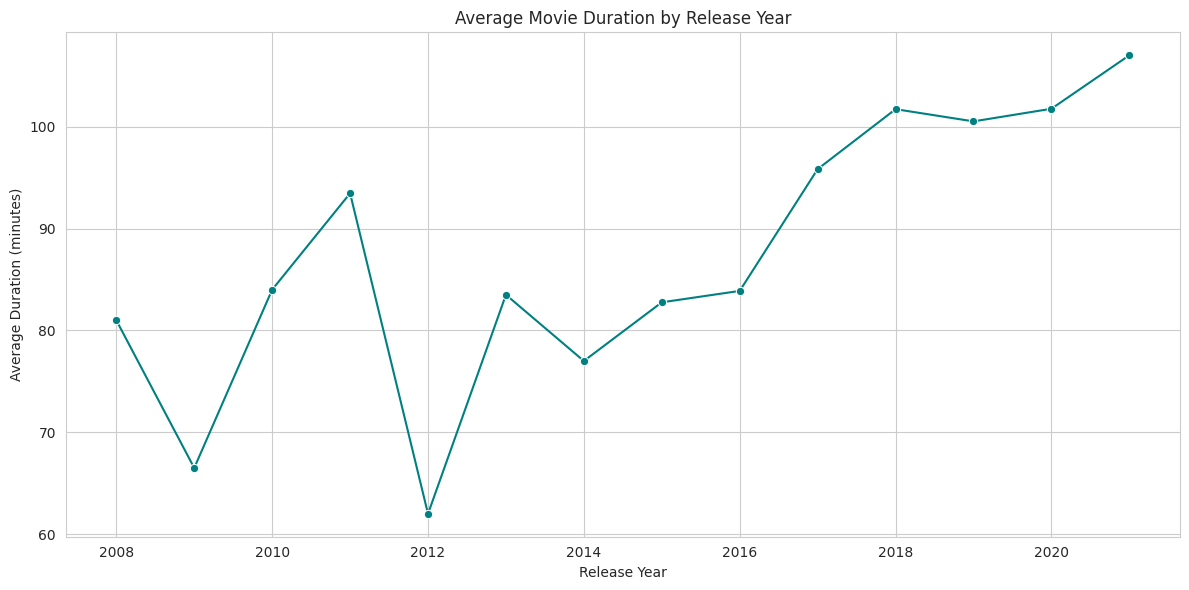

In [29]:
# Do older or newer titles tend to have longer movie durations (has average movie length changed over time)?
movie_df = df[df['Category'] == 'Movie']
avg_duration_by_year = movie_df.groupby('Release_Year')['Duration_Value'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=avg_duration_by_year.index, y=avg_duration_by_year.values, marker='o', color='teal')
plt.title('Average Movie Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.tight_layout()
plt.show()


Director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          10
David Dhawan               9
Kunle Afolayan             8
Name: count, dtype: int64


/tmp/ipykernel_478/3855340898.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')


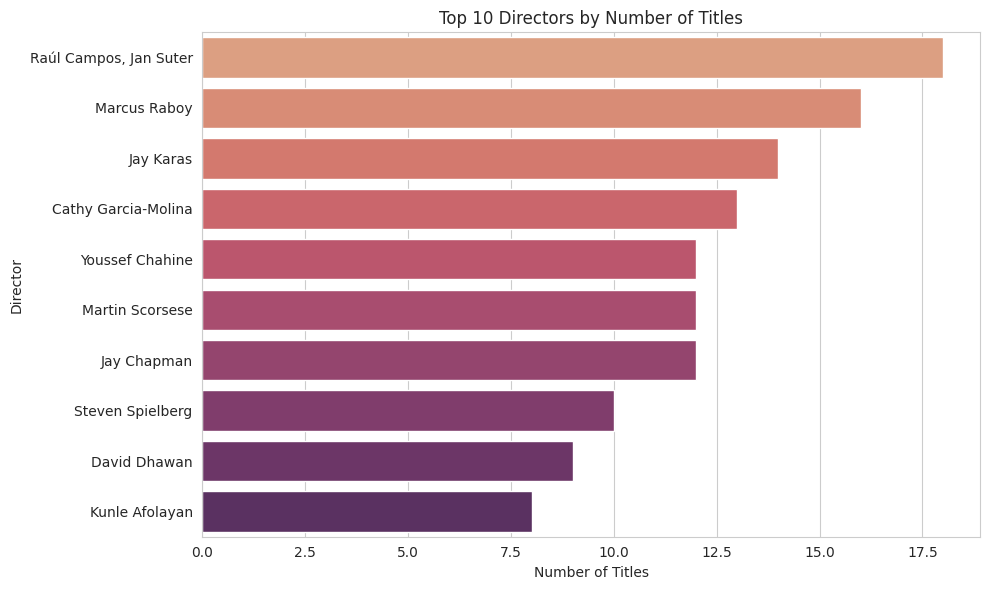

In [30]:
# Which directors have the most titles on Netflix (excluding 'Unknown')?
top_directors = df[df['Director'] != 'Unknown']['Director'].value_counts().head(10)
print(top_directors)

plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()


Cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    30
Om Puri             30
Akshay Kumar        29
Takahiro Sakurai    28
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Name: count, dtype: int64


/tmp/ipykernel_478/4121127414.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cast.values, y=top_cast.index, palette='rocket')


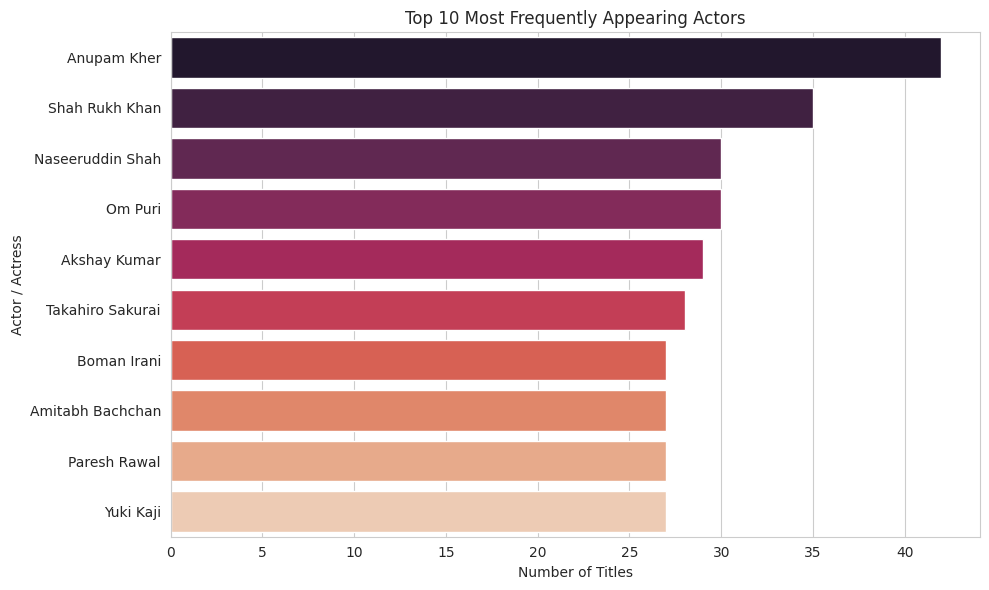

In [31]:
# Which actors/actresses appear in the most titles (Cast column, excluding 'Unknown')?
cast_series = df[df['Cast'] != 'Unknown']['Cast'].str.split(', ').explode()
top_cast = cast_series.value_counts().head(10)
print(top_cast)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cast.values, y=top_cast.index, palette='rocket')
plt.title('Top 10 Most Frequently Appearing Actors')
plt.xlabel('Number of Titles')
plt.ylabel('Actor / Actress')
plt.tight_layout()
plt.show()


## 7. Text Analysis (Description Column)

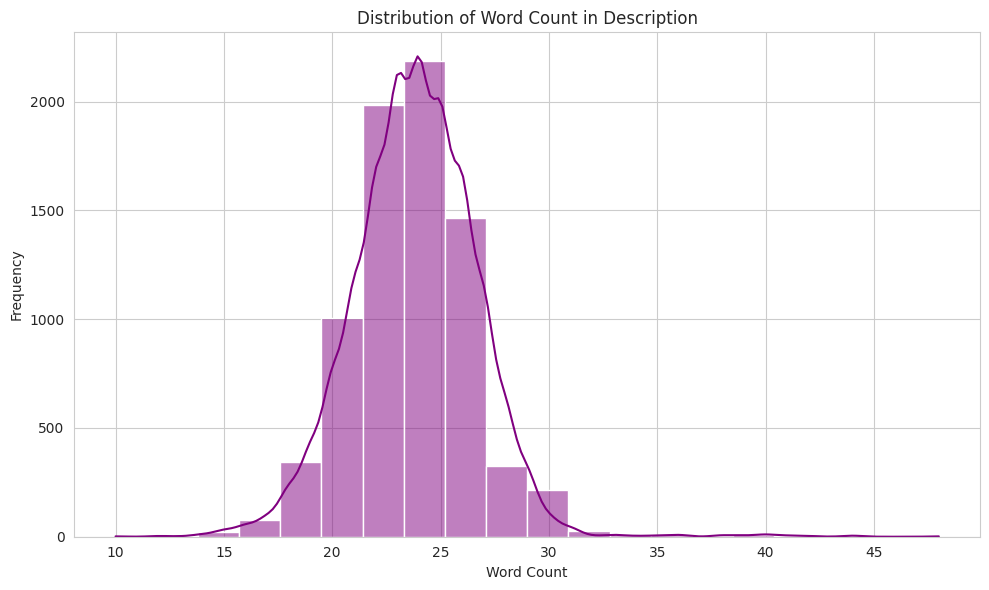

Average description word count: 23.8


In [32]:
# What is the distribution of word counts in the Description column (how long are Netflix synopses)?
df['Description_Word_Count'] = df['Description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,6))
sns.histplot(df['Description_Word_Count'], bins=20, kde=True, color='purple')
plt.title('Distribution of Word Count in Description')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average description word count:", round(df['Description_Word_Count'].mean(), 1))


In [33]:
# What are the most frequently occurring words in the Description column (basic keyword frequency)?
# Basic stopword list to filter out common filler words
stopwords = set(['the','a','an','of','to','in','and','is','his','her','their','on','for',
                  'with','as','after','who','that','this','from','when','by','an','are',
                  'at','into','but','they','her','him','she','he','it','their','its'])

words = ' '.join(df['Description'].astype(str)).lower()
words = ''.join(ch if ch.isalpha() or ch.isspace() else ' ' for ch in words).split()
words = [w for w in words if w not in stopwords and len(w) > 2]

word_freq = Counter(words).most_common(20)
word_freq_df = pd.DataFrame(word_freq, columns=['Word','Frequency'])
word_freq_df


,Word,Frequency
0,life,749
1,young,652
2,new,606
3,family,548
4,man,487
5,world,486
6,love,446
7,two,444
8,woman,427
9,out,403


/tmp/ipykernel_478/2968182394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=word_freq_df, palette='cubehelix')


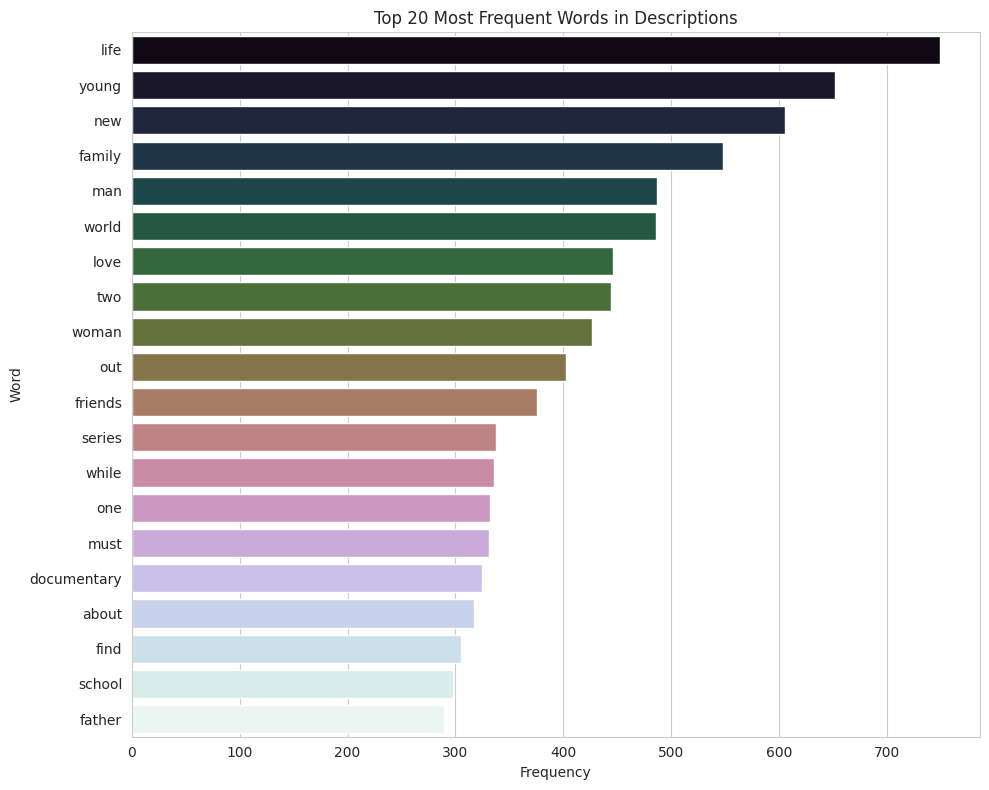

In [34]:
# Can we visualize the top keywords from Description as a bar chart?
plt.figure(figsize=(10,8))
sns.barplot(x='Frequency', y='Word', data=word_freq_df, palette='cubehelix')
plt.title('Top 20 Most Frequent Words in Descriptions')
plt.tight_layout()
plt.show()


## 8. Correlation & Summary Statistics

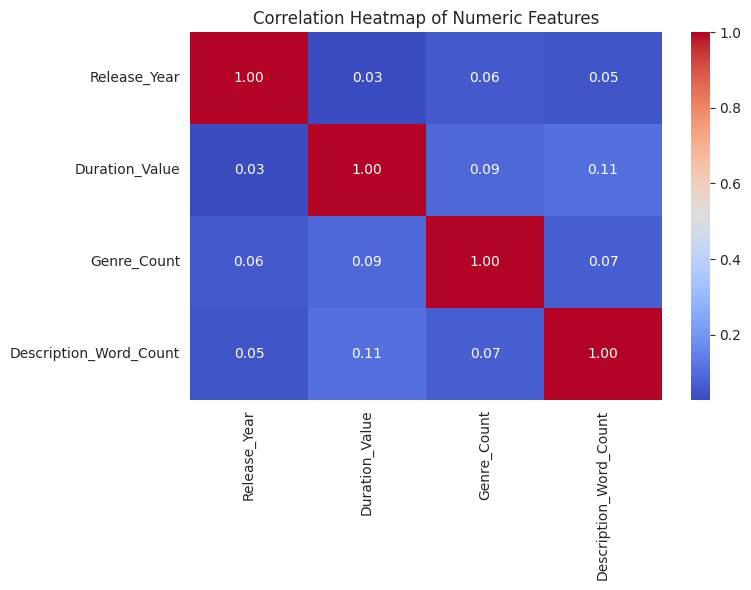

In [35]:
# Is there a correlation between numeric features (Release_Year, Duration_Value, Genre_Count, Description_Word_Count)?
numeric_cols = ['Release_Year', 'Duration_Value', 'Genre_Count', 'Description_Word_Count']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


In [36]:
# What are the overall summary statistics of the numeric columns?
df[numeric_cols].describe()


,Release_Year,Duration_Value,Genre_Count,Description_Word_Count
count,7691.000000,7691.000000,7691.000000,7691.000000
mean,2018.507476,69.962294,2.193993,23.834222
std,1.382141,50.728338,0.785976,2.864827
min,2008.000000,1.000000,1.000000,10.000000
25%,2018.000000,2.000000,2.000000,22.000000
50%,2019.000000,88.000000,2.000000,24.000000
75%,2020.000000,106.000000,3.000000,26.000000
max,2021.000000,312.000000,3.000000,48.000000
